In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Data loading and initial assessment

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.isna().sum()/df.shape[0]*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [6]:
df.duplicated().sum()

0

In [7]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)

# Data cleaning

In [8]:
df.head(0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [9]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

PassengerId    :    0    :    891    :    int64
Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Name    :    0    :    891    :    object
Sex    :    0    :    2    :    object
Age    :    177    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Cabin    :    687    :    147    :    object
Embarked    :    2    :    3    :    object


In [10]:
df = df.drop(columns=['PassengerId','Cabin'])
df.shape

(891, 10)

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    2
dtype: int64

In [12]:
df['Embarked'] = df['Embarked'].fillna(df["Embarked"].mode()[0])
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [13]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Name    :    0    :    891    :    object
Sex    :    0    :    2    :    object
Age    :    0    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Embarked    :    0    :    3    :    object


In [14]:
df['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [15]:
df = df.drop(columns=['Name'])
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [16]:
for c in df.columns:
    print(f"{c}    :    {df[c].isna().sum()}    :    {df[c].nunique()}    :    {df[c].dtypes}")

Survived    :    0    :    2    :    int64
Pclass    :    0    :    3    :    int64
Sex    :    0    :    2    :    object
Age    :    0    :    88    :    float64
SibSp    :    0    :    7    :    int64
Parch    :    0    :    7    :    int64
Ticket    :    0    :    681    :    object
Fare    :    0    :    248    :    float64
Embarked    :    0    :    3    :    object


In [17]:
df['Ticket'].sample(20)

266       3101295
747        250648
864        233866
806        112050
575        358585
425    A/4. 34244
191         28424
680        330935
31       PC 17569
757         29108
745     WE/P 5735
696        363592
212     A/5 21174
179          LINE
441        345769
598          2664
635        237668
818        C 7075
567        349909
365        C 7076
Name: Ticket, dtype: object

In [18]:
df = df.drop(columns=['Ticket'])
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

# Exploratory Data analysis

In [19]:
numeric = df._get_numeric_data()
numeric.dtypes

Survived      int64
Pclass        int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
dtype: object

In [20]:
for c in numeric.columns:
    print(c,":",numeric[c].skew())
    

Survived : 0.4785234382949897
Pclass : -0.6305479068752843
Age : 0.5102446555756496
SibSp : 3.6953517271630556
Parch : 2.7491170471010933
Fare : 4.787316519674893


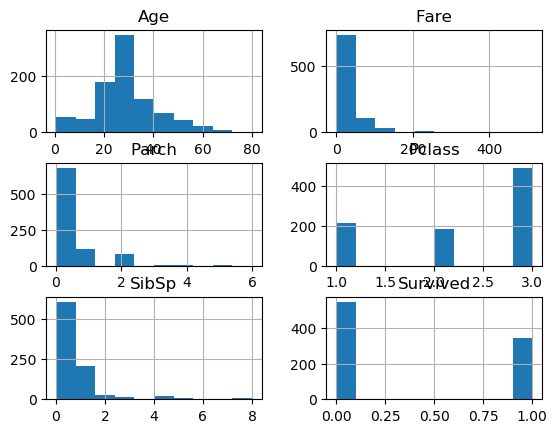

In [21]:
numeric.hist()
plt.show()

In [22]:
numeric.corr()['Survived']

Survived    1.000000
Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Name: Survived, dtype: float64

In [23]:
df.shape

(891, 8)

# preprocessing

In [24]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train = pd.get_dummies(x_train,columns=["Sex","Embarked"]) 
x_test = pd.get_dummies(x_test,columns=["Sex","Embarked"])

In [26]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# model training

In [27]:

model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
p_test = model.predict(x_test)
p_train = model.predict(x_train)

scaled_model = model.fit(x_train_scaled,y_train)
scaled_test_p = model.predict(x_test_scaled)
scaled_train_p  = model.predict(x_train_scaled)

# evaluation

In [28]:
accuracy_test = accuracy_score(y_test,p_test)
accuracy_train = accuracy_score(y_train,p_train)
accuracy_test_scaled = accuracy_score(y_test,scaled_test_p)
accuracy_train_scaled = accuracy_score(y_train,scaled_train_p)
cm_test = confusion_matrix(y_test,p_test)
cm_train = confusion_matrix(y_train,p_train)
cm_scaled_test = confusion_matrix(y_test,scaled_test_p)
cm_scaled_train = confusion_matrix(y_train,scaled_train_p)

In [29]:
print("accuracy test:",accuracy_test)
print("accuracy train:",accuracy_train)
print("scaled test accuracy:",accuracy_test_scaled)
print("scaled train accuracy:",accuracy_train_scaled)
print()
print("cm train:")
print(cm_train)

print("cm test:")
print(cm_test)

print("cm scaled test:",cm_scaled_test)
print("cm scaled train:",cm_scaled_train)

accuracy test: 0.8100558659217877
accuracy train: 0.800561797752809
scaled test accuracy: 0.8044692737430168
scaled train accuracy: 0.800561797752809

cm train:
[[384  60]
 [ 82 186]]
cm test:
[[90 15]
 [19 55]]
cm scaled test: [[90 15]
 [20 54]]
cm scaled train: [[384  60]
 [ 82 186]]


In [30]:
print("test")
print(classification_report(y_test,p_test))

print("train")
print(classification_report(y_train,p_train))

test
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

train
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       444
           1       0.76      0.69      0.72       268

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.80      0.80      0.80       712



/home/yogesh/miniconda3/envs/ds_env/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


0.7613899613899614


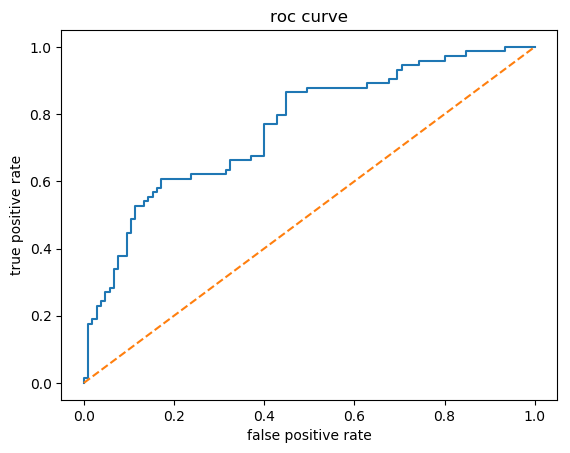

In [31]:
y_prob = model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

auc_score = roc_auc_score(y_test,y_prob)
print(auc_score)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc curve")
plt.show()

# knn model

In [32]:
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(x_train_scaled,y_train)

knn_p_train = model2.predict(x_train_scaled)
knn_p_test = model2.predict(x_test_scaled)

In [33]:
accuracy_test_knn= accuracy_score(y_test,knn_p_test)
accuracy_train_knn = accuracy_score(y_train,knn_p_train)
#cm_scaled_test = confusion_matrix(y_test,knn_p_test)
#cm_scaled_train = confusion_matrix(y_train,knn_p_train)

In [34]:
print("train accuracy")
print(accuracy_train_scaled)

print("test accuracy")
print(accuracy_test_scaled)


train accuracy
0.800561797752809
test accuracy
0.8044692737430168


# optimal k

In [40]:
train_scores = []
test_scores = []

k_values = range(1,21)
for k in k_values:
    model3 = KNeighborsClassifier(
    n_neighbors=k)
    
    model3.fit(x_train_scaled,y_train)
    train_scores.append(model3.score(x_train_scaled,y_train))
    test_scores.append(model3.score(x_test_scaled,y_test))
    
for k,t in zip(k_values,test_scores):
    print(k,round(t,3))

1 0.765
2 0.804
3 0.782
4 0.793
5 0.804
6 0.804
7 0.81
8 0.81
9 0.799
10 0.804
11 0.81
12 0.81
13 0.81
14 0.81
15 0.816
16 0.81
17 0.816
18 0.804
19 0.804
20 0.804
